In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# Load the dataset
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", iris.target_names)

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [5]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [6]:
# Create the random forest model
rf = RandomForestClassifier(n_estimators=100, random_state = 42)

## Conceptually

```
                 Random Forest
                      │
       ┌──────────────┼──────────────┐
       ↓              ↓              ↓
     Tree 1         Tree 2         Tree 3    ... Tree 100
       │              │              │
       ↓              ↓              ↓
   Prediction      Prediction      Prediction
       │              │              │
       └──────────────┼──────────────┘
                      ↓
                 Aggregation
                      ↓
                Final Prediction 

In [7]:
# Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
# Make predictions
y_pred = rf.predict(X_test)

In [9]:
# Evaluate the random forest
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9


In [10]:
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [11]:
print("Number of trees:", len(rf.estimators_))

Number of trees: 100


In [15]:
# See the individual trees
tree_1 = rf.estimators_[0]
tree_2 = rf.estimators_[1]
tree_3 = rf.estimators_[2]

print(tree_1)
print(tree_2)

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)
DecisionTreeClassifier(max_features='sqrt', random_state=1273642419)


In [24]:
# Get predictions from individual trees
sample = X_test[0].reshape(1, -1)
sample

array([[4.4, 3. , 1.3, 0.2]])

In [29]:
individual_predictions = []

for tree in rf.estimators_:
    prediction = int(tree.predict(sample)[0])
    individual_predictions.append(prediction)

print(individual_predictions)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [27]:
# Count the votes
from collections import Counter

votes = Counter(individual_predictions)

print(votes)

Counter({np.float64(0.0): 100})


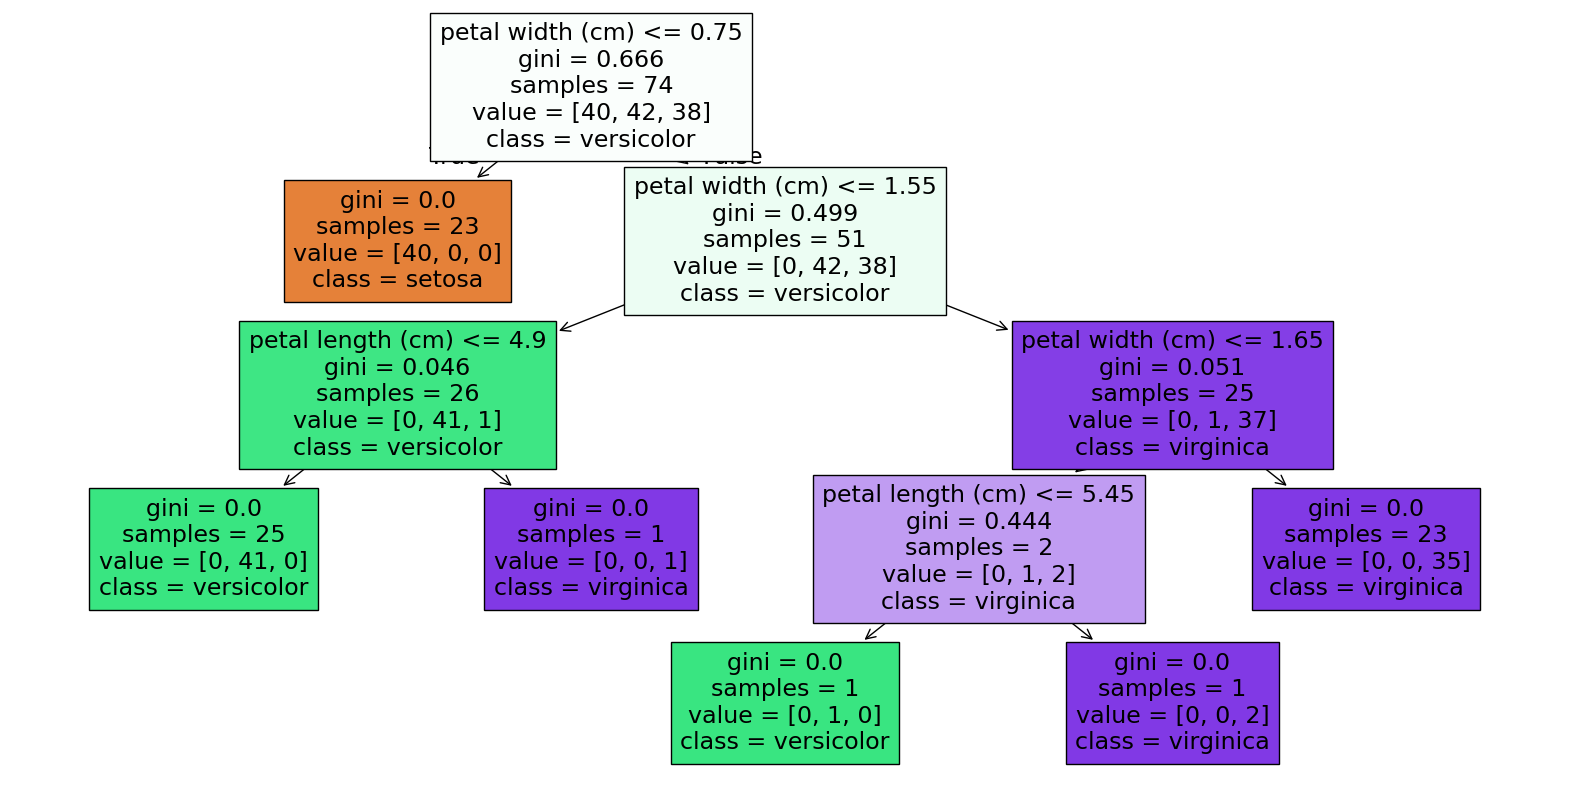

In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    rf.estimators_[0],
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

> That is Random Forest.

> Each tree is an independent model making its own prediction. The forest then combines those individual predictions into one final prediction.

> And this directly connects to the thing you were confused about earlier: the trees are evaluated individually during prediction, but the final ensemble prediction is obtained by aggregating those individual predictions. 🌲🌲🌲